In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("C:\\Users\\ASUS\\OneDrive\\Desktop\\Syntent Technologies\\Student_Performance.csv")
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [3]:
df.shape

(10000, 6)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [5]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [6]:
df.columns.tolist()

['Hours Studied',
 'Previous Scores',
 'Extracurricular Activities',
 'Sleep Hours',
 'Sample Question Papers Practiced',
 'Performance Index']

In [7]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.head()

,hours_studied,previous_scores,extracurricular_activities,sleep_hours,sample_question_papers_practiced,performance_index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [8]:
df.isnull().sum()

hours_studied                       0
previous_scores                     0
extracurricular_activities          0
sleep_hours                         0
sample_question_papers_practiced    0
performance_index                   0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(127)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
le = LabelEncoder()
df['extracurricular_activities'] = le.fit_transform(df['extracurricular_activities'])
df.head()

,hours_studied,previous_scores,extracurricular_activities,sleep_hours,sample_question_papers_practiced,performance_index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


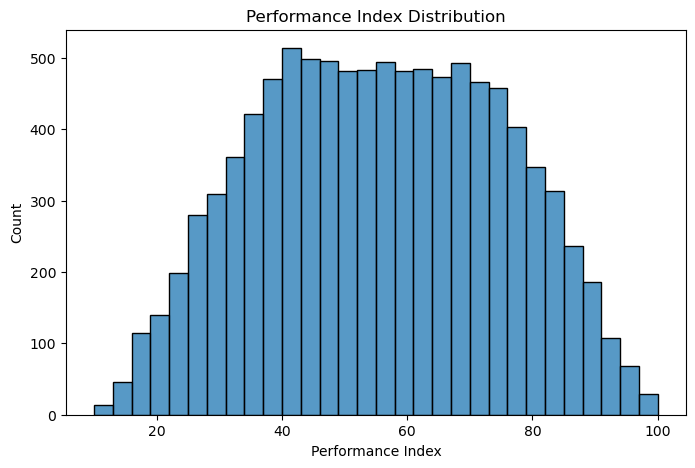

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['performance_index'], bins=30)
plt.title("Performance Index Distribution")
plt.xlabel("Performance Index")
plt.ylabel("Count")
plt.show()

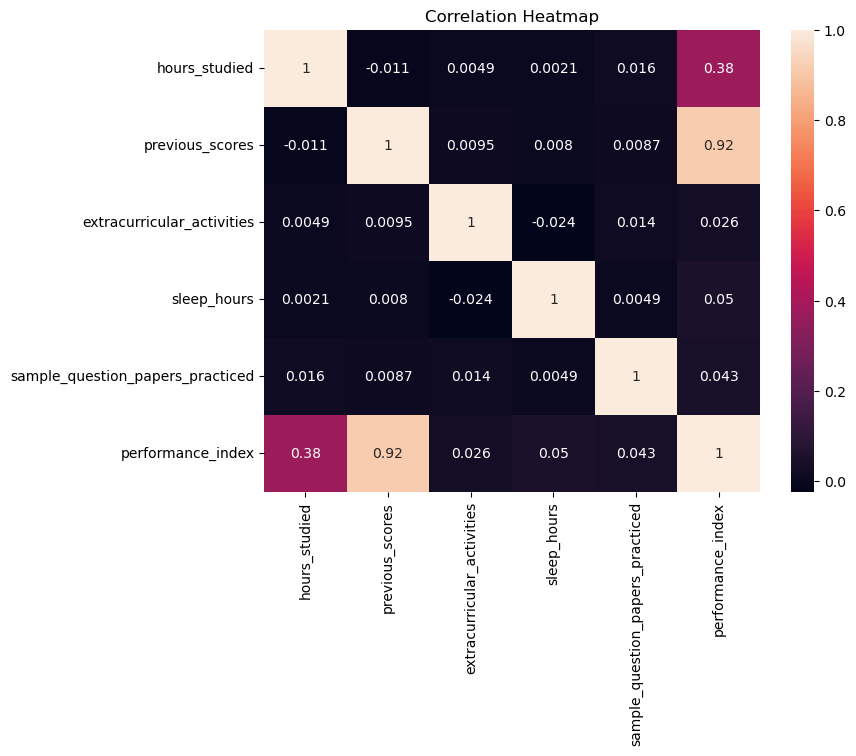

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

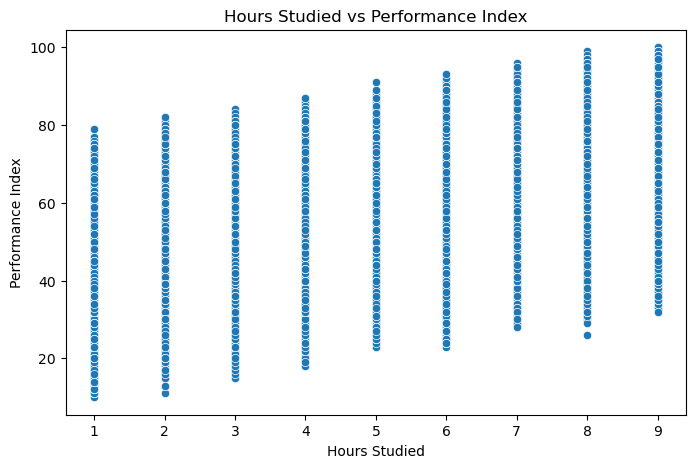

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='hours_studied', y='performance_index')
plt.title("Hours Studied vs Performance Index")
plt.xlabel("Hours Studied")
plt.ylabel("Performance Index")
plt.show()

In [15]:
X = df.drop('performance_index', axis=1)
y = df['performance_index']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [18]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [19]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [20]:
def evaluate_model(y_test, y_pred):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    return rmse, r2

In [21]:
lr_rmse, lr_r2 = evaluate_model(y_test, lr_pred)
dt_rmse, dt_r2 = evaluate_model(y_test, dt_pred)
rf_rmse, rf_r2 = evaluate_model(y_test, rf_pred)

In [22]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'RMSE': [lr_rmse, dt_rmse, rf_rmse],
    'R2 Score': [lr_r2, dt_r2, rf_r2]
})

results

,Model,RMSE,R2 Score
0,Linear Regression,2.075066,0.988430
1,Decision Tree,3.034488,0.975258
2,Random Forest,2.372552,0.984875


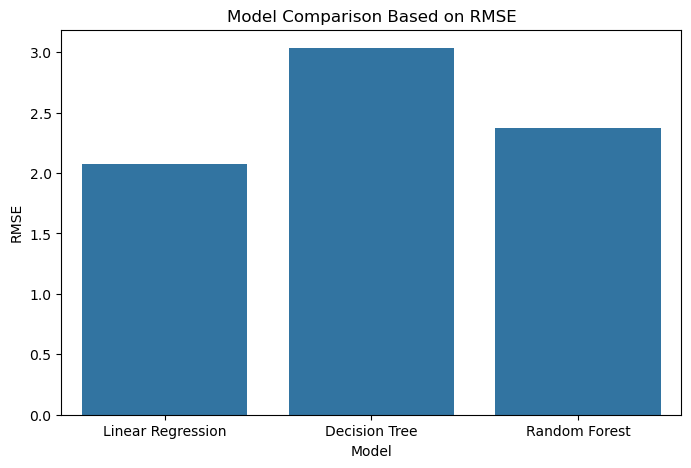

In [23]:
plt.figure(figsize=(8,5))
sns.barplot(data=results, x='Model', y='RMSE')
plt.title("Model Comparison Based on RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.show()

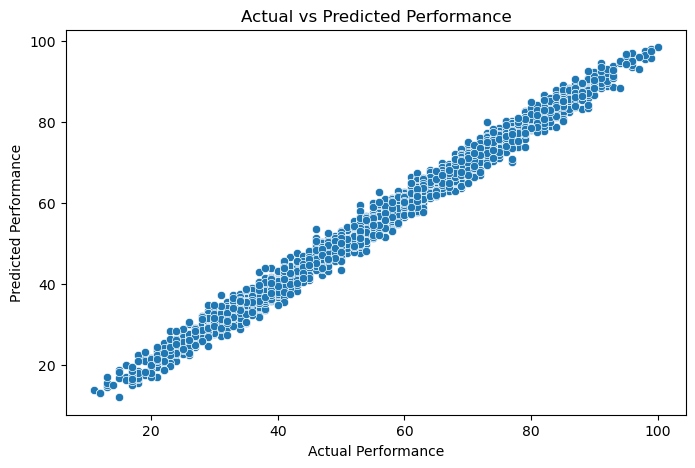

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_test, y=lr_pred)
plt.title("Actual vs Predicted Performance")
plt.xlabel("Actual Performance")
plt.ylabel("Predicted Performance")
plt.show()

In [25]:
best_model = results.sort_values(by='RMSE').iloc[0]
best_model

Model       Linear Regression
RMSE                 2.075066
R2 Score              0.98843
Name: 0, dtype: object

Final Insights:

1. Previous scores and hours studied strongly affect student performance.
2. Linear Regression performed well because the dataset has mostly linear relationships.
3. Random Forest also gave good performance by capturing non-linear patterns.
4. RMSE was used to measure prediction error.
5. The model can help estimate student performance based on academic and lifestyle factors.